In [12]:
import os
os.environ["HF_TOKEN"] = ""  
HF_TOKEN = os.environ.get("HF_TOKEN")
from textgrid import TextGrid
from pathlib import Path
import re
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


In [ ]:
from huggingface_hub import snapshot_download

local_dir = "/home/rohan/Documents/notebooks and csv/notebooks and csv/beat1_text_only"

snapshot_download(
    repo_id="H-Liu1997/BEAT",       # BEAT1 repo
    repo_type="dataset",
    local_dir=local_dir,

    # Download ALL TextGrid files across all speaker subfolders
    allow_patterns=[
        "beat_english_v0.2.1/beat_english_v0.2.1/*/*.TextGrid"
    ]
)

print("Download completed")


Fetching ... files: 226it [00:25,  7.36it/s]

In [17]:
DIRECTION_PHRASES = [
    # --- 1 word ---
   "forward", "back", "behind", "here",
    "inside", "outside", "upstairs", "downstairs", "around", "front",
    "left", "right", "straight", "ahead", "there",
    "near", "nearby", "beside", "above", "below", "across",
    "backward", "backwards", "toward", "towards", "opposite",

    # --- 2 words ---
    "go left", "go right", "go straight", "go forward", "go back",
    "turn left", "turn right",
    "head left", "head right",
    "walk straight", "move forward",
    "over there", "right there", "just there", "right here", "over here",
    "this way", "that way",
    "next to", "in front", "behind you", "nearby location",
    "at corner", "by stairs", "near entrance",
    "straight ahead", "up ahead", "up there", "down there",
    "go ahead", "go over", "go up", "go down",
    "head forward", "head back", "head straight",
    "walk left", "walk right", "walk forward", "walk back", "walk ahead",
    "move left", "move right", "move back", "move ahead",
    "turn around", "turn back",
    "come here", "come over", "come back", "come up", "come down",
    "look here", "look there",
    "left side", "right side", "front side", "back side",
    "left corner", "right corner", "front corner", "back corner",
    "near exit", "near platform", "near stairs", "near entrance", "near door",
    "near gate", "near elevator", "near escalator",
    "by exit", "by platform", "by entrance", "by door", "by gate",
    "by elevator", "by escalator",
    "at exit", "at platform", "at entrance", "at door", "at gate",
    "at elevator", "at escalator", "at stairs",
    "on left", "on right", "to left", "to right", "to front", "to back",
    "far away", "next door", "right beside", "left beside",
    "right behind", "right ahead", "left ahead",
    "back there", "back here", "just here", "out front", "in back",

    # --- 3 words ---
    "go to platform", "go to exit", "go to train",
    "head to exit", "walk to platform",
    "on your left", "on your right",
    "in front of", "next to platform",
    "across from entrance",
    "keep going straight", "continue going straight",
    "turn to left", "turn to right",
    "go straight ahead",
    "right over there", "just over there",
    "on this side", "on that side",
    "on the left", "on the right",
    "at the corner", "by the stairs", "near the entrance",
    "to your left", "to your right", "to the left", "to the right",
    "left of you", "right of you", "right behind you",
    "right in front", "right next to", "just in front",
    "near the exit", "near the platform", "near the stairs", "near the entrance",
    "near the door", "near the gate", "near the elevator", "near the escalator",
    "by the exit", "by the platform", "by the entrance", "by the door",
    "by the gate", "by the elevator", "by the escalator", "by the stairs",
    "at the exit", "at the platform", "at the entrance", "at the door",
    "at the gate", "at the elevator", "at the escalator", "at the stairs",
    "go to entrance", "go to stairs", "go to elevator", "go to escalator",
    "go to gate", "go to door", "go to lobby", "go to station",
    "go to counter", "go to ticket", "go to kiosk", "go to hallway", "go to hall",
    "head to entrance", "head to platform", "head to stairs", "head to elevator",
    "head to escalator", "head to gate", "head to door", "head to lobby",
    "head to station", "head to counter", "head to ticket", "head to kiosk",
    "head to hallway", "head to hall",
    "walk to exit", "walk to entrance", "walk to stairs", "walk to elevator",
    "walk to escalator", "walk to gate", "walk to door", "walk to lobby",
    "walk to station", "walk to counter", "walk to ticket", "walk to kiosk",
    "walk to hallway", "walk to hall",
    "go up stairs", "go down stairs", "go up escalator", "go down escalator",
    "take the stairs", "take the elevator", "take the escalator",
    "down the hall", "down the hallway", "up the stairs", "down the stairs",
    "across from you", "across the hall", "across the room",
    "right over here", "just over here",
    "keep walking straight", "keep moving straight", "continue straight ahead",
    "continue straight on", "keep going ahead", "keep moving ahead", "keep walking ahead",
    "go straight on", "go straight forward",
    "in the front", "in the back", "at the front", "at the back",
    "left hand side", "right hand side",
    "over on left", "over on right", "over to left", "over to right",

    # --- 4 words ---
    "go straight then left",
    "go straight then right",
    "first go straight then",
    "then turn to left",
    "then turn to right",
    "after that go left",
    "after that go right",
    "you should go left",
    "you should go right",
    "you can go straight",
    "you need to go left",
    "you need to go right",
    "walk straight to platform",
    "head straight to exit",
    "go over to platform",
    "go over to exit",
    "over on the left", "over on the right",
    "over to the left", "over to the right",
    "on the left side", "on the right side",
    "on your left side", "on your right side",
    "in front of you", "across from the entrance",
    "go to the exit", "go to the platform", "go to the entrance",
    "go to the stairs", "go to the elevator", "go to the escalator",
    "go to the gate", "go to the door", "go to the train",
    "go to the lobby", "go to the station", "go to the counter",
    "go to the ticket", "go to the kiosk", "go to the hallway", "go to the hall",
    "head to the exit", "head to the platform", "head to the entrance",
    "head to the stairs", "head to the elevator", "head to the escalator",
    "head to the gate", "head to the door", "head to the lobby",
    "head to the station", "head to the counter", "head to the ticket",
    "head to the kiosk", "head to the hallway", "head to the hall",
    "walk to the exit", "walk to the platform", "walk to the entrance",
    "walk to the stairs", "walk to the elevator", "walk to the escalator",
    "walk to the gate", "walk to the door", "walk to the lobby",
    "walk to the station", "walk to the counter", "walk to the ticket",
    "walk to the kiosk", "walk to the hallway", "walk to the hall",
    "go straight and left", "go straight and right",
    "just to the left", "just to the right",
    "straight ahead of you", "right next to you",
    "right in front of", "just in front of", "just behind you",
    "across from the exit", "across from the platform",
    "across from the stairs", "across from the door",
    "across from the gate", "across from the elevator", "across from the escalator",
    "at the end of", "at the back of", "at the front of",

    # --- 5 words ---
    "go straight and then left", "go straight and then right",
    "go straight then turn left", "go straight then turn right",
    "go straight then go left", "go straight then go right",
    "walk straight then left", "walk straight then right",
    "head straight then left", "head straight then right",
    "go ahead and turn left", "go ahead and turn right",
    "keep going then left", "keep going then right",
    "continue straight then left", "continue straight then right",
    "right in front of you", "right over on the left", "right over on the right",
    "just to your left", "just to your right",
]

sample_counts = defaultdict(int)   
keyword_counts = Counter()         

textgrid_dir = Path("/home/rohan/Documents/notebooks and csv/notebooks and csv/beat1_text_only/beat_english_v0.2.1/beat_english_v0.2.1")

# -------- MATCH FUNCTIONS --------
def match_keywords_upgrade(text):
    # normalize whitespace and lowercase
    text = re.sub(r"\s+", " ", text.lower().strip())

    matches = []
    # sort phrases by word count / length so longer phrases are attempted first
    phrases_sorted = sorted(DIRECTION_PHRASES, key=lambda s: (-len(s.split()), -len(s)))

    for k in phrases_sorted:
        # build pattern that allows one-or-more whitespace between words
        parts = [re.escape(p) for p in k.split()]
        pattern = rf"\b{r'\s+'.join(parts)}\b"
        for m in re.finditer(pattern, text):
            matches.append(k)
            # optional: remove matched span from text to avoid overlapping double-counts
            # start, end = m.span()
            # text = text[:start] + " " * (end - start) + text[end:]
            # break   # uncomment to only take first match of this phrase per text
    return matches

# -------- MAIN LOOP --------
# We will group contiguous word intervals into "segments" by short pauses so multi-word
# phrases that span multiple TextGrid intervals are found.
PAUSE_THRESHOLD = 0.6  # seconds: pause longer than this starts a new line/segment

for file in textgrid_dir.rglob("*.TextGrid"):
    tg = TextGrid.fromFile(str(file))

    # find 'words' tier (fallback to first interval tier if missing)
    words_tier = None
    for tier in tg.tiers:
        if tier.name.lower() == "words":
            words_tier = tier
            break
    if words_tier is None:
        for tier in tg.tiers:
            # interval tier detection: has items with .mark
            try:
                _ = [iv.mark for iv in tier]
                words_tier = tier
                break
            except Exception:
                continue
    if words_tier is None:
        continue

    # Build contiguous segments: merge consecutive non-empty words unless a pause > threshold
    segments = []  # each entry: (start_time, end_time, text)
    current_words = []
    current_start = None
    current_end = None

    for iv in words_tier:
        w = iv.mark.strip() if hasattr(iv, 'mark') else str(iv.text).strip()
        if w == "":
            # treat as silence; if we have a current segment, close it if the silence is long
            if current_words:
                # extend end to current_end
                segments.append((current_start, current_end, " ".join(current_words)))
                current_words = []
                current_start = None
                current_end = None
            continue

        # non-empty word
        if current_start is None:
            current_start = iv.minTime
            current_end = iv.maxTime
            current_words = [w]
        else:
            gap = iv.minTime - current_end
            if gap > PAUSE_THRESHOLD:
                # close previous segment
                segments.append((current_start, current_end, " ".join(current_words)))
                # start new segment
                current_start = iv.minTime
                current_end = iv.maxTime
                current_words = [w]
            else:
                # continue current segment
                current_words.append(w)
                current_end = iv.maxTime

    # flush last
    if current_words:
        segments.append((current_start, current_end, " ".join(current_words)))

    # Search each segment with upgraded matcher
    matched_any = False
    for start, end, seg_text in segments:
        found = match_keywords_upgrade(seg_text)
        if found:
            matched_any = True
            sample_counts[file.name] += len(found)
            keyword_counts.update(found)

    # (optional) also check the entire tier text as a fallback to catch matches across accidental
    # segment boundaries (but we avoid double-counting by only doing this when no segment matched)
    if not matched_any:
        full_text = " ".join([iv.mark.strip() for iv in words_tier if getattr(iv, 'mark', '').strip()])
        fallback_found = match_keywords_upgrade(full_text)
        if fallback_found:
            sample_counts[file.name] += len(fallback_found)
            keyword_counts.update(fallback_found)

# -------- RESULTS --------
print("Total samples:", len(sample_counts))
print("Top samples:", sorted(sample_counts.items(), key=lambda x: x[1], reverse=True)[:5])
print("Keyword distribution:", keyword_counts)

Total samples: 1552
Top samples: [('2_scott_1_7_7.TextGrid', 65), ('2_scott_1_4_4.TextGrid', 54), ('4_lawrence_1_10_10.TextGrid', 52), ('19_jaime_1_2_2.TextGrid', 46), ('2_scott_1_6_6.TextGrid', 45)]
Keyword distribution: Counter({'there': 2681, 'right': 863, 'around': 682, 'back': 624, 'here': 494, 'left': 178, 'inside': 159, 'front': 153, 'in front': 107, 'near': 104, 'in front of': 104, 'go back': 95, 'outside': 73, 'across': 70, 'behind': 69, 'above': 55, 'next to': 53, 'this way': 48, 'come back': 47, 'forward': 46, 'straight': 37, 'over there': 31, 'go up': 31, 'towards': 30, 'in front of you': 30, 'go over': 30, 'come here': 30, 'that way': 27, 'left side': 26, 'to the left': 20, 'opposite': 20, 'far away': 19, 'to the right': 15, 'at the end of': 15, 'come over': 13, 'turn around': 11, 'on your right': 11, 'up there': 11, 'come up': 10, 'in back': 10, 'right there': 9, 'head back': 8, 'walk right': 8, 'just there': 7, 'on your left': 7, 'on the right': 6, 'right in front of': 6

In [21]:
sample_counts

defaultdict(int,
            {'4_lawrence_0_109_109.TextGrid': 1,
             '4_lawrence_0_6_6.TextGrid': 1,
             '4_lawrence_0_63_63.TextGrid': 2,
             '4_lawrence_0_112_112.TextGrid': 1,
             '4_lawrence_0_77_77.TextGrid': 3,
             '4_lawrence_0_26_26.TextGrid': 7,
             '4_lawrence_0_5_5.TextGrid': 1,
             '4_lawrence_1_1_1.TextGrid': 11,
             '4_lawrence_0_111_111.TextGrid': 4,
             '4_lawrence_1_10_10.TextGrid': 52,
             '4_lawrence_0_86_86.TextGrid': 5,
             '4_lawrence_0_42_42.TextGrid': 2,
             '4_lawrence_0_100_100.TextGrid': 6,
             '4_lawrence_0_12_12.TextGrid': 6,
             '4_lawrence_0_52_52.TextGrid': 5,
             '4_lawrence_0_95_95.TextGrid': 3,
             '4_lawrence_0_35_35.TextGrid': 1,
             '4_lawrence_0_92_92.TextGrid': 2,
             '4_lawrence_0_37_37.TextGrid': 1,
             '4_lawrence_0_25_25.TextGrid': 1,
             '4_lawrence_1_2_2.TextGrid

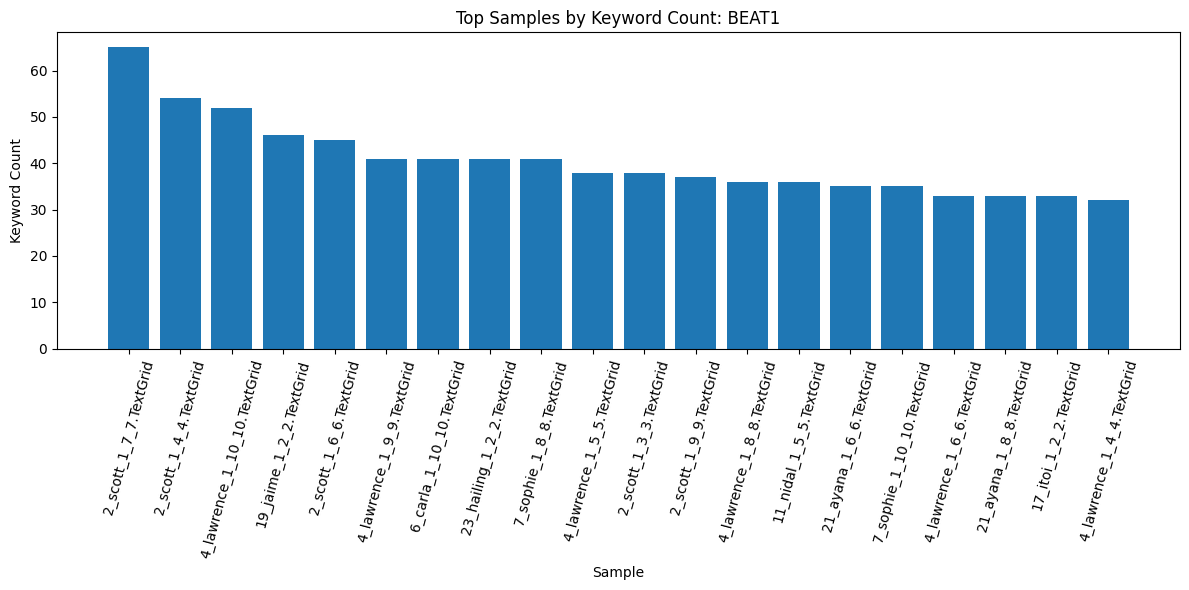

In [22]:
# sort samples
top_samples = sorted(sample_counts.items(), key=lambda x: x[1], reverse=True)[:20]

labels = [s for s, _ in top_samples]
counts = [c for _, c in top_samples]

plt.figure(figsize=(12, 6))
plt.bar(labels, counts)

plt.title("Top Samples by Keyword Count: BEAT1")
plt.xlabel("Sample")
plt.ylabel("Keyword Count")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

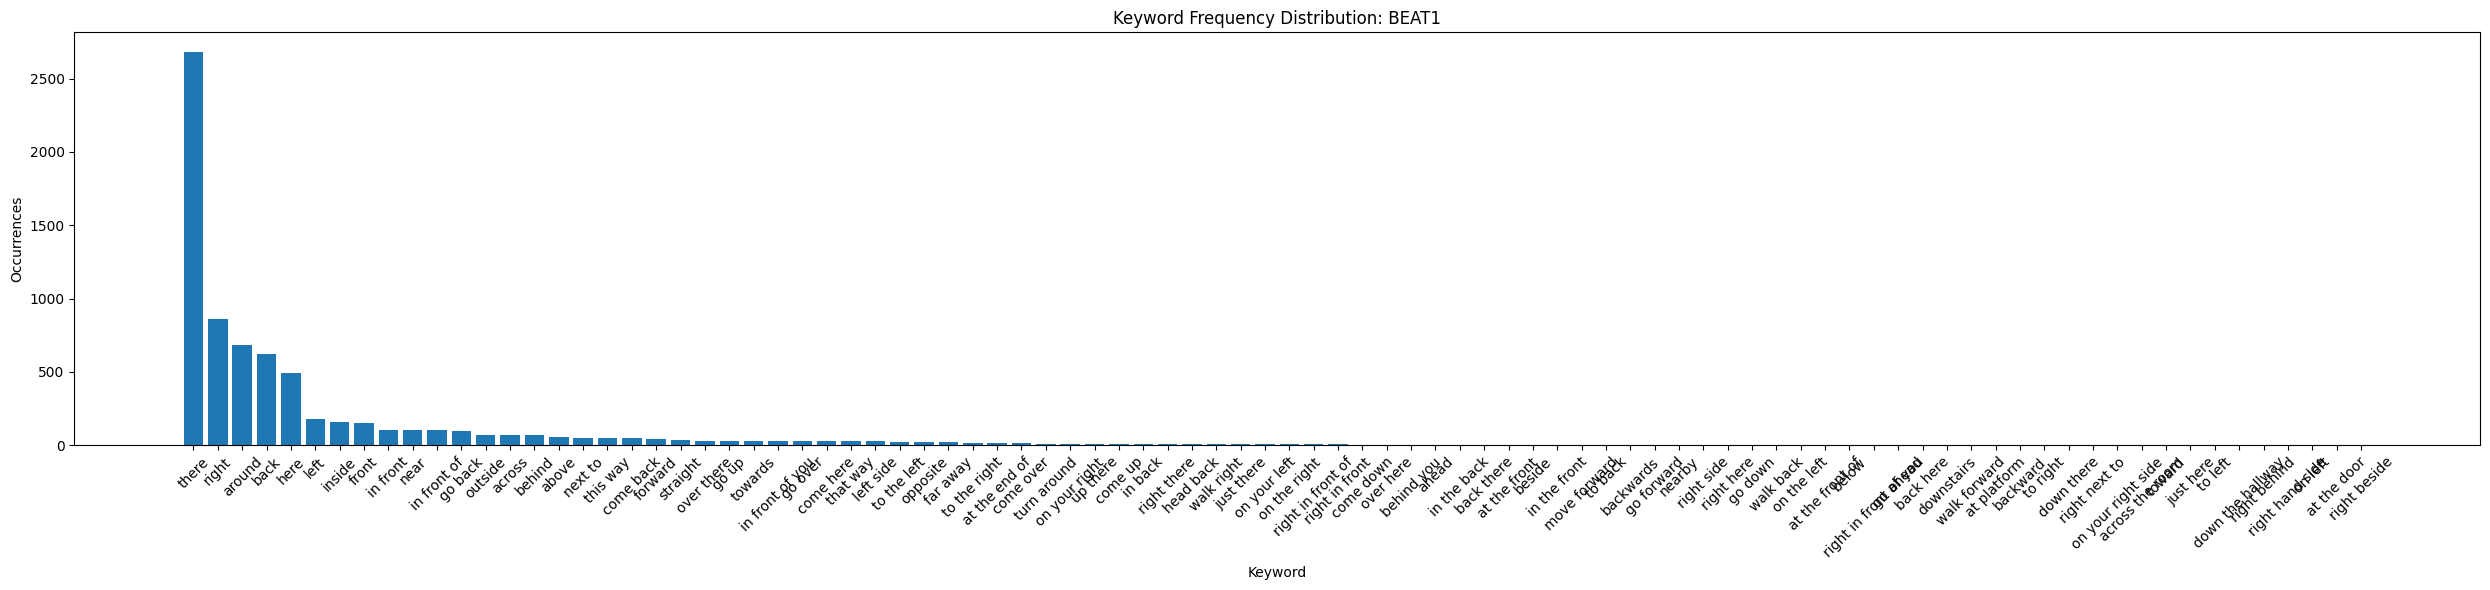

In [48]:
# sort keywords
sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)

labels = [k for k, _ in sorted_keywords]
counts = [c for _, c in sorted_keywords]

plt.figure(figsize=(25, 6))
plt.bar(labels, counts)

plt.title("Keyword Frequency Distribution: BEAT1")
plt.xlabel("Keyword")
plt.ylabel("Occurrences")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## In the next cells we are collecting bvh and wav files for samples where more than 5 words occur. It was performed to gain valid samples. However, this approach didn't work out. Gained samples do not cover our use case. 

In [24]:
MIN_KEYWORDS = 5

sample_ids = [
    s.replace(".TextGrid", "")
    for s, count in sample_counts.items()
    if count >= MIN_KEYWORDS
]

print("Samples to download:", len(sample_ids))
print(sample_ids[:5])

Samples to download: 443
['4_lawrence_0_26_26', '4_lawrence_1_1_1', '4_lawrence_1_10_10', '4_lawrence_0_86_86', '4_lawrence_0_100_100']


In [25]:
patterns = []

# BEAT1: files are at beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sample_id}.bvh
# Extract speaker_id from sample filename: e.g. "1_wayne_0_100_100" → speaker_id = "1"
for sid in sample_ids:
    speaker_id = sid.split("_")[0]
    patterns.append(f"beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sid}.bvh")

# OPTIONAL: audio (same folder structure)
for sid in sample_ids:
    speaker_id = sid.split("_")[0]
    patterns.append(f"beat_english_v0.2.1/beat_english_v0.2.1/{speaker_id}/{sid}.wav")

print(f"Total patterns: {len(patterns)}")
print("Example:", patterns[:2])


Total patterns: 886
Example: ['beat_english_v0.2.1/beat_english_v0.2.1/4/4_lawrence_0_26_26.bvh', 'beat_english_v0.2.1/beat_english_v0.2.1/4/4_lawrence_1_1_1.bvh']


In [26]:
from huggingface_hub import snapshot_download

local_dir = "/Users/romangogolev/beat1_selected"

snapshot_download(
    repo_id="H-Liu1997/BEAT",       # BEAT1 repo
    repo_type="dataset",
    local_dir=local_dir,
    allow_patterns=patterns
)

print("Download completed")


Fetching ... files: 0it [00:00, ?it/s]


PermissionError: [Errno 13] Permission denied: '/Users'

In [ ]:
from pathlib import Path

# -------- CONFIG --------
# BEAT1: BVH files are nested in per-speaker subfolders
base_dir = Path("/home/rohan/Documents/notebooks and csv/notebooks and csv/beat1_text_only/beat_english_v0.2.1/beat_english_v0.2.1")

# -------- COLLECT --------
results = []

# Use rglob to find BVH files across all speaker subfolders
for bvh_file in base_dir.rglob("*.bvh"):
    try:
        # Count frames by reading the BVH header (fast, no full parse needed)
        frames = 0
        with open(bvh_file, "r") as f:
            for line in f:
                line = line.strip()
                if line.startswith("Frames:"):
                    frames = int(line.split(":")[1].strip())
                    break

        sample_id = bvh_file.stem
        results.append((sample_id, frames))

    except Exception as e:
        print(f"Error reading {bvh_file.name}: {e}")

# -------- SORT --------
results.sort(key=lambda x: x[1])  # by frames ascending

# -------- TOP 5 --------
top5 = results[:5]

print(f"Total BVH files found: {len(results)}")
print("\nTop-5 smallest samples:")
for sample_id, frames in top5:
    print(f"  {sample_id} → {frames} frames")


Error reading 30_katya_1_1_1.bvh: invalid literal for int() with base 10: '74437.0'
Error reading 14_zhang_1_2_2.bvh: invalid literal for int() with base 10: '71940.0'
Total BVH files found: 71

Top-5 smallest samples:
  8_catherine_0_84_84 → 4680 frames
  7_sophie_0_84_84 → 5520 frames
  16_jorge_0_111_111 → 6000 frames
  1_wayne_0_84_84 → 6240 frames
  4_lawrence_0_84_84 → 8040 frames


In [27]:
results

NameError: name 'results' is not defined

## From our view, another approach is better: to make short extract from samples in which keywords were occurred.

In [7]:
# Collect multi-word keyword windows per sample: [sample_id, phrase, frame_rate_min, frame_rate_max]
from pathlib import Path
from textgrid import TextGrid
import re

# Config
TEXTGRID_DIR = Path("/home/rohan/Documents/notebooks and csv/notebooks and csv/beat1_text_only/beat_english_v0.2.1")
PAUSE_THRESHOLD = 0.6  # seconds
PADDING = 5.0          # seconds padding before/after

# Ensure DIRECTION_PHRASES exists; fall back to the list in this cell if not
try:
    D_PHRASES = DIRECTION_PHRASES
except NameError:
    D_PHRASES = DIRECTION_PHRASES = [
        # minimal fallback (you likely already have the full list)
        "go left", "go right", "one time i was in vietnam"
    ]

# Helper: find multi-word phrases in a text (returns list of phrase strings)
def find_multiword_phrases(text, phrases):
    txt = re.sub(r"\s+", " ", text.lower().strip())
    results = []
    phrases_sorted = sorted(phrases, key=lambda s: (-len(s.split()), -len(s)))
    for k in phrases_sorted:
        if len(k.split()) < 2:
            continue
        parts = [re.escape(p) for p in k.split()]
        pattern = rf"\b{r'\s+'.join(parts)}\b"
        for m in re.finditer(pattern, txt):
            results.append(k)
    return results

# Output array
candidate_windows = []  # list of [sample_id, phrase, start_sec, end_sec]

for tg_file in TEXTGRID_DIR.rglob("*.TextGrid"):
    try:
        tg = TextGrid.fromFile(str(tg_file))
    except Exception:
        continue

    # find words tier
    words_tier = None
    for t in tg.tiers:
        if getattr(t, 'name', '').lower() == 'words':
            words_tier = t
            break
    if words_tier is None:
        # fallback to first interval-like tier
        for t in tg.tiers:
            try:
                _ = [iv.mark for iv in t]
                words_tier = t
                break
            except Exception:
                continue
    if words_tier is None:
        continue

    # compute audio / tier duration (use max end time)
    try:
        duration = max(iv.maxTime for iv in words_tier)
    except Exception:
        duration = None

    # build segments of contiguous words separated by pauses > PAUSE_THRESHOLD
    segments = []  # (start, end, text)
    cur_words = []
    cur_start = None
    cur_end = None

    for iv in words_tier:
        w = iv.mark.strip() if hasattr(iv, 'mark') else str(getattr(iv, 'text', '')).strip()
        if w == "":
            if cur_words:
                segments.append((cur_start, cur_end, " ".join(cur_words)))
                cur_words = []
                cur_start = cur_end = None
            continue

        if cur_start is None:
            cur_start = iv.minTime
            cur_end = iv.maxTime
            cur_words = [w]
        else:
            gap = iv.minTime - cur_end
            if gap > PAUSE_THRESHOLD:
                segments.append((cur_start, cur_end, " ".join(cur_words)))
                cur_start = iv.minTime
                cur_end = iv.maxTime
                cur_words = [w]
            else:
                cur_words.append(w)
                cur_end = iv.maxTime

    if cur_words:
        segments.append((cur_start, cur_end, " ".join(cur_words)))

    sample_id = tg_file.stem

    # search each segment for multi-word phrases
    for seg_start, seg_end, seg_text in segments:
        found = find_multiword_phrases(seg_text, D_PHRASES)
        for phrase in found:
            start_win = max(0.0, (seg_start - PADDING) if seg_start is not None else 0.0)
            end_win = (seg_end + PADDING) if seg_end is not None else None
            if duration is not None and end_win is not None:
                end_win = min(end_win, duration)
            # append [sample_id, phrase, start_sec, end_sec]
            candidate_windows.append([sample_id, phrase, round(start_win, 3), round(end_win if end_win is not None else start_win + PADDING, 3)])

# summary
print(f"Collected {len(candidate_windows)} windows (multi-word phrases).")
print("First 20 entries:")
for item in candidate_windows[:20]:
    print(item)

# keep candidate_windows in notebook namespace for later use


Collected 1023 windows.
First 20 entries:
['4_lawrence_1_10_10', 'over there', 13.53, 17.86]
['4_lawrence_1_10_10', 'go back', 149.02, 153.29]
['4_lawrence_1_10_10', 'go back to', 149.02, 153.35]
['4_lawrence_0_12_12', 'on the other side', 45.85, 50.84]
['4_lawrence_0_52_52', 'go back', 45.46, 49.8]
['4_lawrence_0_52_52', 'walk through', 53.04, 58.0]
['4_lawrence_0_92_92', 'turn around', 4.05, 8.6]
['4_lawrence_1_2_2', 'go into', 542.61, 547.85]
['4_lawrence_0_65_65', 'in front', 15.69, 20.01]
['4_lawrence_0_65_65', 'in front of', 15.69, 20.07]
['4_lawrence_0_17_17', 'walk into', 43.89, 48.73]
['4_lawrence_0_56_56', 'walk into', 37.89, 42.77]
['4_lawrence_0_29_29', 'go back', 63.59, 68.25]
['4_lawrence_0_28_28', 'in front', 37.42, 42.16]
['4_lawrence_0_28_28', 'in front of', 37.42, 42.71]
['4_lawrence_0_28_28', 'on the left', 42.66, 48.1]
['4_lawrence_0_28_28', 'on your right', 45.7, 50.85]
['4_lawrence_1_8_8', 'go through', 93.88, 98.41]
['4_lawrence_1_8_8', 'at the end', 120.79, 125.

In [ ]:
import csv
out_path = "/home/rohan/Documents/notebooks and csv/notebooks and csv/beat1_candidate_windows_v2.csv"

with open(out_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["sample_id", "phrase", "start_sec", "end_sec"])
    for sample_id, phrase, start, end in candidate_windows:
        writer.writerow([sample_id, phrase, start, end])

print("Saved CSV:", out_path)

Saved CSV: /Users/romangogolev/beat1_candidate_windows.csv


## Now we got a valuable table with information which part of each sample to extract. However, it would be reprocessed by another script to get rid of duplicates.